In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')

In [32]:
def get_sine_data(n_samples, noise_std):

    x = np.sort(np.random.uniform(0, 6, n_samples))

    y_true = np.sin(x)

    noise = np.random.normal(0, noise_std, n_samples)
    y_noisy = y_true + noise

    return x, y_noisy

In [33]:
NOISE_LEVELS = [0.1, 0.5, 1.0]
SAMPLE_SIZES = [10, 50, 100]
DEGREE = 3
NUM_RUNS = 10
CONFIDENCE_Z = 1.96

results_table = []

x_eval = np.linspace(0, 6, 100)
y_true_eval = np.sin(x_eval)

for n_samples in SAMPLE_SIZES:
    for sigma in NOISE_LEVELS:

        all_predictions = []
        mse_scores = []

        for i in range(NUM_RUNS):
            x_train, y_train = get_sine_data(n_samples, sigma)

            coeffs = np.polyfit(x_train, y_train, DEGREE)
            poly_model = np.poly1d(coeffs)

            y_pred = poly_model(x_eval)
            all_predictions.append(y_pred)

            mse = np.mean((y_pred - y_true_eval)**2)
            mse_scores.append(mse)

        all_predictions = np.array(all_predictions)

        std_dev = np.std(all_predictions, axis=0)

        # Confidence Interval Width = Upper Bound - Lower Bound
        # Width = (Mean + Z*Std) - (Mean - Z*Std) = 2 * Z * Std
        ci_width_curve = 2 * CONFIDENCE_Z * std_dev

        avg_ci_width = np.mean(ci_width_curve)
        avg_mse = np.mean(mse_scores)

        results_table.append({
            "Samples (N)": n_samples,
            "Noise (Sigma)": sigma,
            "Avg Error (MSE)": round(avg_mse, 4),
            "Avg CI Width": round(avg_ci_width, 4)
        })

df = pd.DataFrame(results_table)
print("\n EXPERIMENT RESULTS TABLE")
display(df)


 EXPERIMENT RESULTS TABLE


,Samples (N),Noise (Sigma),Avg Error (MSE),Avg CI Width
0,10,0.1,0.0720,0.7460
1,10,0.5,1.2366,2.7403
2,10,1.0,1.0307,3.2861
3,50,0.1,0.0051,0.1221
4,50,0.5,0.0268,0.5550
5,50,1.0,0.0885,0.9849
6,100,0.1,0.0048,0.1057
7,100,0.5,0.0143,0.3707
8,100,1.0,0.0766,0.8634


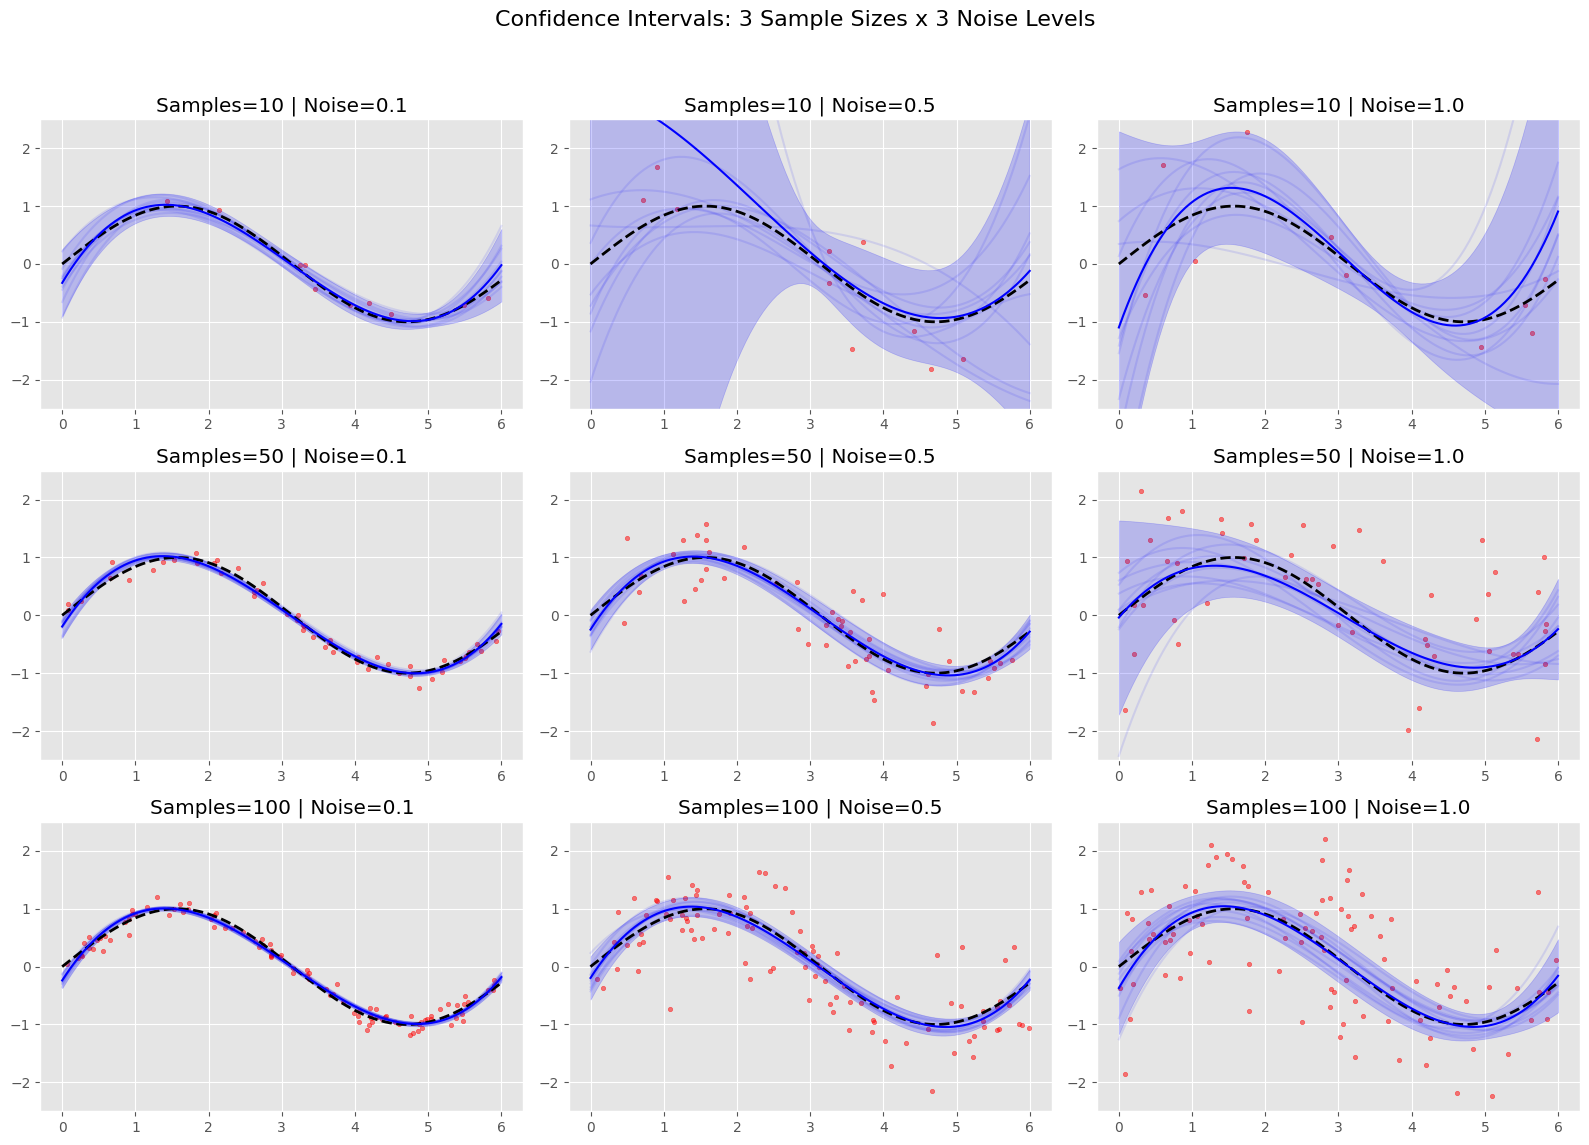

In [34]:
NOISE_LEVELS = [0.1, 0.5, 1.0]
SAMPLE_SIZES = [10, 50, 100]
DEGREE = 3
CONFIDENCE_Z = 1.96              #for 95% Confidence

fig, axes = plt.subplots(len(SAMPLE_SIZES), len(NOISE_LEVELS), figsize=(16, 12))
fig.suptitle(f"Confidence Intervals: {len(SAMPLE_SIZES)} Sample Sizes x {len(NOISE_LEVELS)} Noise Levels", fontsize=16)

x_eval = np.linspace(0, 6, 100)
y_true_eval = np.sin(x_eval)

for row_idx, n_samples in enumerate(SAMPLE_SIZES):
    for col_idx, sigma in enumerate(NOISE_LEVELS):

        ax = axes[row_idx, col_idx]

        preds = []

        for i in range(10):
            x, y = get_sine_data(n_samples, sigma)

            p = np.poly1d(np.polyfit(x, y, DEGREE))
            y_pred = p(x_eval)
            preds.append(y_pred)

            ax.plot(x_eval, y_pred, color='blue', alpha=0.1)

            if i == 0:
                ax.scatter(x, y, color='red', s=10, alpha=0.5, label='Noisy Data')

        preds = np.array(preds)
        mean_pred = np.mean(preds, axis=0)
        std_pred = np.std(preds, axis=0)

        upper = mean_pred + (CONFIDENCE_Z * std_pred)
        lower = mean_pred - (CONFIDENCE_Z * std_pred)


        ax.plot(x_eval, y_true_eval, 'k--', linewidth=2, label='True Sin(x)')

        ax.plot(x_eval, mean_pred, 'b-', linewidth=1.5, label='Mean Prediction')

        ax.fill_between(x_eval, lower, upper, color='blue', alpha=0.2, label='95% CI')

        ax.set_title(f"Samples={n_samples} | Noise={sigma}")
        ax.set_ylim(-2.5, 2.5)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

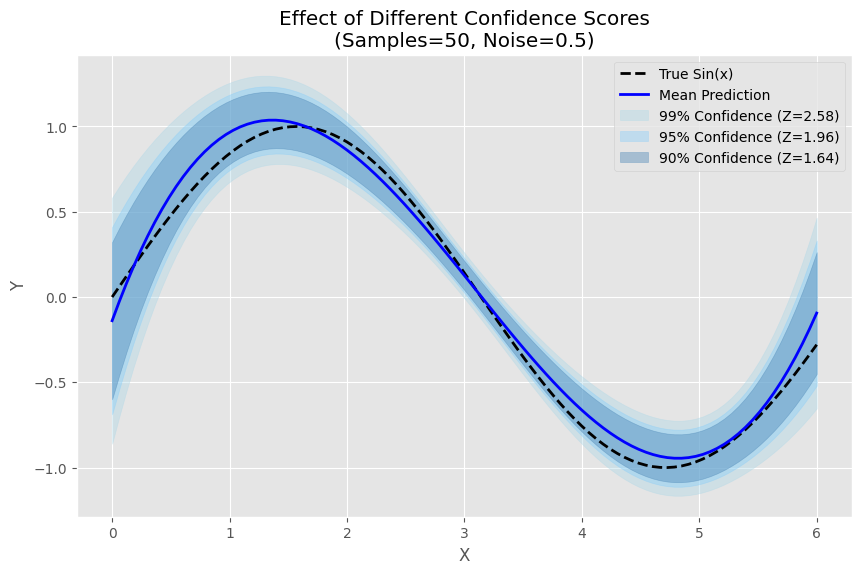

In [35]:
from scipy import stats

N_SAMPLES = 50
SIGMA = 0.5
DEGREE = 3
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]

preds = []
for i in range(10):
    x, y = get_sine_data(N_SAMPLES, SIGMA)
    p = np.poly1d(np.polyfit(x, y, DEGREE))
    preds.append(p(x_eval))

preds = np.array(preds)
mean_pred = np.mean(preds, axis=0)
std_pred = np.std(preds, axis=0)

plt.figure(figsize=(10, 6))
plt.title(f"Effect of Different Confidence Scores\n(Samples={N_SAMPLES}, Noise={SIGMA})")

plt.plot(x_eval, y_true_eval, 'k--', linewidth=2, label='True Sin(x)')
plt.plot(x_eval, mean_pred, 'b-', linewidth=2, label='Mean Prediction')

colors = ['#ADD8E6', '#87CEFA', '#4682B4']

sorted_levels = sorted(CONFIDENCE_LEVELS, reverse=True)

for idx, conf_level in enumerate(sorted_levels):
    # Calculate Z-score automatically using scipy
    # 0.90 -> 1.645 | 0.95 -> 1.96 | 0.99 -> 2.576
    z_score = stats.norm.ppf((1 + conf_level) / 2)

    upper = mean_pred + (z_score * std_pred)
    lower = mean_pred - (z_score * std_pred)

    label = f"{int(conf_level*100)}% Confidence (Z={z_score:.2f})"
    plt.fill_between(x_eval, lower, upper, color=colors[idx], alpha=0.4, label=label)

plt.legend(loc='upper right')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()